# Member 4 - Decision Tree Regressor
## Medical Insurance Charges Prediction

### Objective
The objective of this model is to predict medical insurance charges using a Decision Tree Regressor and identify a suitable tree configuration through hyperparameter tuning.

### Model Suitability
Decision Tree Regression is suitable for predicting the continuous target variable `charges`. It can capture nonlinear relationships and interactions between features without assuming a linear relationship.

This is useful for insurance data because factors such as age, BMI, smoking status, and other patient characteristics may interact in complex ways when determining medical charges.

Decision Trees are also relatively interpretable because predictions are produced using a sequence of decision rules.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
candidate_roots = [
    Path("."),
    Path("..")
]

project_root = None

for root in candidate_roots:

    train_file = (
        root
        / "data"
        / "processed"
        / "insurance_train_processed.csv"
    )

    test_file = (
        root
        / "data"
        / "processed"
        / "insurance_test_processed.csv"
    )

    if train_file.exists() and test_file.exists():
        project_root = root
        break


if project_root is None:
    raise FileNotFoundError(
        "Processed train/test CSV files were not found. "
        "Check the data/processed folder."
    )


TRAIN_PATH = (
    project_root
    / "data"
    / "processed"
    / "insurance_train_processed.csv"
)

TEST_PATH = (
    project_root
    / "data"
    / "processed"
    / "insurance_test_processed.csv"
)

RESULT_PATH = (
    project_root
    / "results"
    / "model_results"
)

FIGURE_PATH = (
    project_root
    / "results"
    / "model_visualizations"
)


RESULT_PATH.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_PATH.mkdir(
    parents=True,
    exist_ok=True
)


print("Project root :", project_root)
print("Train file   :", TRAIN_PATH)
print("Test file    :", TEST_PATH)

Project root : ..
Train file   : ..\data\processed\insurance_train_processed.csv
Test file    : ..\data\processed\insurance_test_processed.csv


In [3]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)


print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape :", test_df.shape)


print("\nTraining Data:")
display(train_df.head())


print("\nTesting Data:")
display(test_df.head())


print(
    "\nTraining Missing Values:",
    train_df.isnull().sum().sum()
)

print(
    "Testing Missing Values:",
    test_df.isnull().sum().sum()
)


if "charges" not in train_df.columns:
    raise ValueError(
        "'charges' target column is missing from training data."
    )

if "charges" not in test_df.columns:
    raise ValueError(
        "'charges' target column is missing from testing data."
    )

Training Dataset Shape: (1069, 8)
Testing Dataset Shape : (268, 8)

Training Data:


,smoker_yes,age_bmi_interaction,age,bmi,region_southeast,children,sex_male,charges
0,0,-1.238193,-1.157680,-1.002462,0,-0.907908,1,2396.09590
1,0,-1.282622,-1.300619,-0.796635,0,0.766904,1,3279.86855
2,0,1.432285,0.914926,1.166632,0,0.766904,0,33471.97189
3,0,2.705024,1.701087,1.824110,1,-0.907908,1,13405.39030
4,0,0.082968,0.557580,-0.654140,0,0.766904,0,9715.84100



Testing Data:


,smoker_yes,age_bmi_interaction,age,bmi,region_southeast,children,sex_male,charges
0,0,-0.199877,0.700518,-1.334950,0,-0.907908,1,8688.85885
1,0,-0.894330,-0.728865,-0.820801,0,2.441716,0,5708.86700
2,0,1.248171,0.843457,0.976639,0,1.604310,0,11436.73815
3,1,-0.271365,-0.585927,0.644150,0,1.604310,1,38746.35510
4,0,-0.032718,-0.585927,1.310794,1,0.766904,1,4463.20510



Training Missing Values: 0
Testing Missing Values: 0


In [4]:
X_train = train_df.drop(
    columns=["charges"]
)

y_train = train_df["charges"]


X_test = test_df.drop(
    columns=["charges"]
)

y_test = test_df["charges"]


if list(X_train.columns) != list(X_test.columns):
    raise ValueError(
        "Training and testing feature columns do not match."
    )


print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)

print("X_test Shape :", X_test.shape)
print("y_test Shape :", y_test.shape)


print("\nFeatures Used:")

for feature in X_train.columns:
    print("-", feature)


print("\nTarget Statistics:")
display(y_train.describe())

X_train Shape: (1069, 7)
y_train Shape: (1069,)
X_test Shape : (268, 7)
y_test Shape : (268,)

Features Used:
- smoker_yes
- age_bmi_interaction
- age
- bmi
- region_southeast
- children
- sex_male

Target Statistics:


count     1069.000000
mean     13030.203369
std      11706.530971
min       1121.873900
25%       4747.052900
50%       9290.139500
75%      16450.894700
max      62592.873090
Name: charges, dtype: float64

In [5]:
def evaluate_model(
    model_name,
    y_true,
    y_pred
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )


    print(f"\n{model_name}")
    print("-" * 50)

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")


    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

## Evaluation, Validation and Implementation

### Evaluation Metrics
The model is evaluated using:

- **MAE:** Measures the average absolute prediction error. Lower values indicate better performance.
- **RMSE:** Gives a larger penalty to large prediction errors. Lower values indicate better performance.
- **R²:** Measures how much variation in insurance charges is explained by the model. Higher values generally indicate better performance.

### Validation and Hyperparameter Tuning
Five-fold cross-validation is used during GridSearchCV to evaluate different Decision Tree configurations.

The following hyperparameters are tuned:

- **max_depth:** Controls the maximum depth of the tree and helps control model complexity.
- **min_samples_split:** Specifies the minimum number of samples required to split an internal node.
- **min_samples_leaf:** Specifies the minimum number of samples required at a leaf node.

### Implementation
Scikit-learn `DecisionTreeRegressor` is used to build the model and `GridSearchCV` is used for hyperparameter tuning. A default Decision Tree is first evaluated as a baseline and then compared with the tuned model.

In [6]:
tree_baseline = DecisionTreeRegressor(
    random_state=42
)


tree_baseline.fit(
    X_train,
    y_train
)


baseline_predictions = (
    tree_baseline.predict(
        X_test
    )
)


baseline_result = evaluate_model(
    "Decision Tree - Baseline",
    y_test,
    baseline_predictions
)


print(
    "\nBaseline Tree Depth:",
    tree_baseline.get_depth()
)

print(
    "Baseline Number of Leaves:",
    tree_baseline.get_n_leaves()
)


Decision Tree - Baseline
--------------------------------------------------
MAE  : 3229.1490
RMSE : 6835.6081
R²   : 0.7457

Baseline Tree Depth: 25
Baseline Number of Leaves: 1069


In [7]:
param_grid = {
    "max_depth": [
        3,
        5,
        7,
        10,
        15,
        None
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],

    "min_samples_leaf": [
        1,
        2,
        4
    ]
}


tree_model = DecisionTreeRegressor(
    random_state=42
)


grid_search = GridSearchCV(
    estimator=tree_model,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)


grid_search.fit(
    X_train,
    y_train
)


print(
    "Best Parameters:",
    grid_search.best_params_
)

print(
    "Best Cross-Validation RMSE:",
    -grid_search.best_score_
)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best Cross-Validation RMSE: 4823.4108947777295


In [8]:
cv_results = pd.DataFrame(
    grid_search.cv_results_
)


tuning_results = pd.DataFrame({
    "Max_Depth":
        cv_results["param_max_depth"],

    "Min_Samples_Split":
        cv_results[
            "param_min_samples_split"
        ].astype(int),

    "Min_Samples_Leaf":
        cv_results[
            "param_min_samples_leaf"
        ].astype(int),

    "Mean_Train_RMSE":
        -cv_results["mean_train_score"],

    "Mean_CV_RMSE":
        -cv_results["mean_test_score"],

    "CV_RMSE_STD":
        cv_results["std_test_score"]
})


tuning_results = (
    tuning_results
    .sort_values(
        "Mean_CV_RMSE"
    )
    .reset_index(
        drop=True
    )
)


print(
    "Top 10 Decision Tree Configurations:"
)

display(
    tuning_results.head(10)
)

Top 10 Decision Tree Configurations:


,Max_Depth,Min_Samples_Split,Min_Samples_Leaf,Mean_Train_RMSE,Mean_CV_RMSE,CV_RMSE_STD
0,5,10,4,4214.534967,4823.410895,432.634339
1,5,2,4,4212.360204,4824.504465,435.314112
2,5,5,4,4212.360204,4824.504465,435.314112
3,5,10,2,4198.734647,4842.647870,433.601830
4,5,5,2,4195.820108,4843.046643,437.172561
5,5,2,2,4195.820108,4843.046643,437.172561
6,5,5,1,4148.581857,4845.244326,393.566481
7,5,2,1,4134.574165,4845.401078,393.495362
8,5,10,1,4152.458596,4845.888399,393.854685
9,3,2,4,4576.492465,4930.599107,481.413752


In [9]:
best_tree_model = (
    grid_search.best_estimator_
)


best_params = (
    grid_search.best_params_
)


tuned_predictions = (
    best_tree_model.predict(
        X_test
    )
)


tuned_result = evaluate_model(
    "Decision Tree - Tuned",
    y_test,
    tuned_predictions
)


print("\nBest Parameters:")

for parameter, value in best_params.items():
    print(
        f"{parameter}: {value}"
    )


print(
    "\nTuned Tree Depth:",
    best_tree_model.get_depth()
)

print(
    "Tuned Number of Leaves:",
    best_tree_model.get_n_leaves()
)


Decision Tree - Tuned
--------------------------------------------------
MAE  : 2600.3061
RMSE : 4353.4819
R²   : 0.8969

Best Parameters:
max_depth: 5
min_samples_leaf: 4
min_samples_split: 10

Tuned Tree Depth: 5
Tuned Number of Leaves: 31


In [10]:
tree_results = pd.DataFrame([
    baseline_result,
    tuned_result
])


tree_results = (
    tree_results
    .sort_values(
        by="RMSE"
    )
    .reset_index(
        drop=True
    )
)


print(
    "Baseline vs Tuned Decision Tree:"
)

display(
    tree_results
)

Baseline vs Tuned Decision Tree:


,Model,MAE,RMSE,R2
0,Decision Tree - Tuned,2600.306097,4353.481923,0.896859
1,Decision Tree - Baseline,3229.148983,6835.608133,0.745720


In [11]:
cv_scores = cross_val_score(

    best_tree_model,

    X_train,

    y_train,

    cv=5,

    scoring="neg_root_mean_squared_error",

    n_jobs=-1
)


cv_rmse_scores = -cv_scores


print(
    "Final Decision Tree - 5-Fold CV RMSE Scores:"
)


for fold, score in enumerate(
    cv_rmse_scores,
    start=1
):

    print(
        f"Fold {fold}: {score:.4f}"
    )


print(
    f"\nMean CV RMSE: "
    f"{cv_rmse_scores.mean():.4f}"
)

print(
    f"CV RMSE Standard Deviation: "
    f"{cv_rmse_scores.std():.4f}"
)

Final Decision Tree - 5-Fold CV RMSE Scores:
Fold 1: 5592.7299
Fold 2: 4563.9388
Fold 3: 4584.6592
Fold 4: 4385.4263
Fold 5: 4990.3003

Mean CV RMSE: 4823.4109
CV RMSE Standard Deviation: 432.6343


In [12]:
final_tree_result = evaluate_model(
    "Decision Tree - Final Tuned Model",
    y_test,
    tuned_predictions
)


feature_importance = pd.DataFrame({
    "Feature":
        X_train.columns,

    "Importance":
        best_tree_model.feature_importances_
})


feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print("\nFeature Importance:")

display(
    feature_importance
)


print(
    "\nMean 5-Fold CV RMSE:",
    round(
        cv_rmse_scores.mean(),
        4
    )
)


Decision Tree - Final Tuned Model
--------------------------------------------------
MAE  : 2600.3061
RMSE : 4353.4819
R²   : 0.8969

Feature Importance:


,Feature,Importance
0,smoker_yes,0.692335
1,bmi,0.171621
2,age,0.093674
3,age_bmi_interaction,0.030061
4,children,0.011880
5,region_southeast,0.000429
6,sex_male,0.000000



Mean 5-Fold CV RMSE: 4823.4109


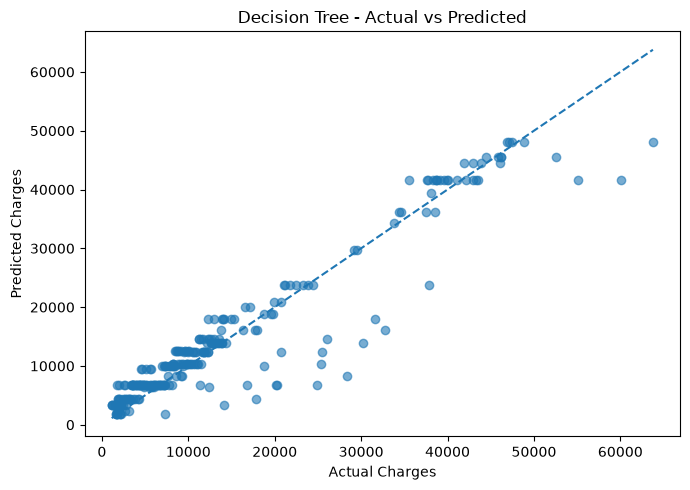

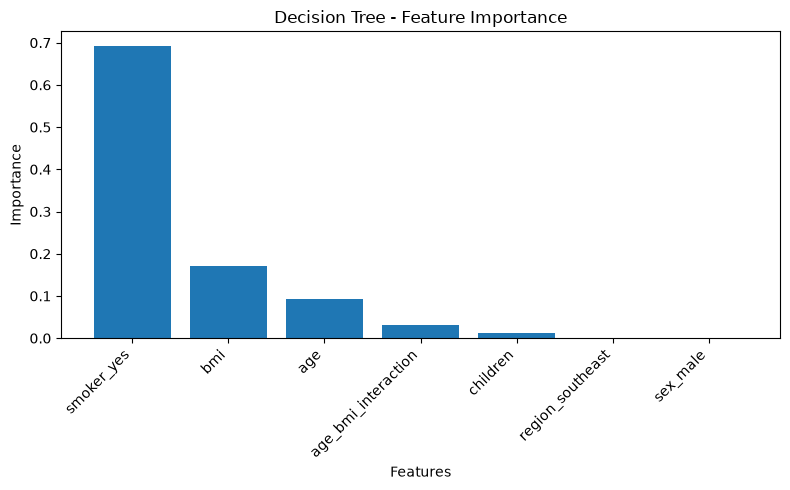

In [13]:
# Actual vs Predicted
plt.figure(
    figsize=(7, 5)
)


plt.scatter(
    y_test,
    tuned_predictions,
    alpha=0.6
)


minimum_value = min(
    y_test.min(),
    tuned_predictions.min()
)

maximum_value = max(
    y_test.max(),
    tuned_predictions.max()
)


plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    "--"
)


plt.xlabel(
    "Actual Charges"
)

plt.ylabel(
    "Predicted Charges"
)

plt.title(
    "Decision Tree - Actual vs Predicted"
)


plt.tight_layout()


plt.savefig(
    FIGURE_PATH
    / "decision_tree_actual_vs_predicted.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# ---------------------------------------
# Feature Importance Plot
# ---------------------------------------

plt.figure(
    figsize=(8, 5)
)


plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)


plt.xlabel(
    "Features"
)

plt.ylabel(
    "Importance"
)

plt.title(
    "Decision Tree - Feature Importance"
)


plt.xticks(
    rotation=45,
    ha="right"
)


plt.tight_layout()


plt.savefig(
    FIGURE_PATH
    / "decision_tree_feature_importance.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()

In [14]:
# Baseline vs tuned results
tree_results.to_csv(

    RESULT_PATH
    / "decision_tree_results.csv",

    index=False
)


# GridSearchCV tuning results
tuning_results.to_csv(

    RESULT_PATH
    / "decision_tree_tuning_results.csv",

    index=False
)


# Feature importance
feature_importance.to_csv(

    RESULT_PATH
    / "decision_tree_feature_importance.csv",

    index=False
)


# Final result for group comparison
best_tree_result = pd.DataFrame([
    {
        "Model":
            "Decision Tree Regressor",

        "Best_Configuration":
            str(best_params),

        "MAE":
            final_tree_result["MAE"],

        "RMSE":
            final_tree_result["RMSE"],

        "R2":
            final_tree_result["R2"],

        "CV_RMSE":
            cv_rmse_scores.mean()
    }
])


best_tree_result.to_csv(

    RESULT_PATH
    / "decision_tree_best.csv",

    index=False
)


print("Decision Tree Results:")
display(tree_results)


print("\nTop 10 Tuning Results:")
display(
    tuning_results.head(10)
)


print("\nFeature Importance:")
display(
    feature_importance
)


print("\nBest Decision Tree Result:")
display(
    best_tree_result
)


print("\nResults saved successfully.")

Decision Tree Results:


,Model,MAE,RMSE,R2
0,Decision Tree - Tuned,2600.306097,4353.481923,0.896859
1,Decision Tree - Baseline,3229.148983,6835.608133,0.745720



Top 10 Tuning Results:


,Max_Depth,Min_Samples_Split,Min_Samples_Leaf,Mean_Train_RMSE,Mean_CV_RMSE,CV_RMSE_STD
0,5,10,4,4214.534967,4823.410895,432.634339
1,5,2,4,4212.360204,4824.504465,435.314112
2,5,5,4,4212.360204,4824.504465,435.314112
3,5,10,2,4198.734647,4842.647870,433.601830
4,5,5,2,4195.820108,4843.046643,437.172561
5,5,2,2,4195.820108,4843.046643,437.172561
6,5,5,1,4148.581857,4845.244326,393.566481
7,5,2,1,4134.574165,4845.401078,393.495362
8,5,10,1,4152.458596,4845.888399,393.854685
9,3,2,4,4576.492465,4930.599107,481.413752



Feature Importance:


,Feature,Importance
0,smoker_yes,0.692335
1,bmi,0.171621
2,age,0.093674
3,age_bmi_interaction,0.030061
4,children,0.011880
5,region_southeast,0.000429
6,sex_male,0.000000



Best Decision Tree Result:


,Model,Best_Configuration,MAE,RMSE,R2,CV_RMSE
0,Decision Tree Regressor,"{'max_depth': 5, 'min_samples_leaf': 4, 'min_s...",2600.306097,4353.481923,0.896859,4823.410895



Results saved successfully.


## Conclusion, Limitations and Improvements

### Conclusion
A baseline Decision Tree and multiple tuned Decision Tree configurations were evaluated. GridSearchCV with five-fold cross-validation was used to test different combinations of `max_depth`, `min_samples_split`, and `min_samples_leaf`.

The baseline and tuned models were compared using MAE, RMSE, and R². Feature importance was also examined to understand which input features contributed most to the tree's predictions. The tuned Decision Tree result is saved for the final group-level model comparison.

### Limitations
- Decision Trees can overfit the training data when the tree becomes too deep or complex.
- Small changes in the training data can sometimes produce different tree structures.
- A single Decision Tree may have lower generalization ability than ensemble tree methods.
- Feature importance indicates how useful features were to the fitted tree, but it should not automatically be interpreted as a causal relationship.

### Possible Improvements
- Further tune tree complexity and pruning-related parameters.
- Investigate additional feature engineering.
- Compare the model with ensemble methods such as Random Forest.
- Use repeated or additional validation strategies to examine model stability.